# Test AutoML


#### Mettre dans le bon path

In [16]:
import os
import sys
from pathlib import Path

# remonte d'un niveau depuis le cwd du notebook
root = Path.cwd().parent
os.chdir(root)  # ← change le dossier courant

src = root / "src"
if src.exists() and str(src) not in sys.path:
    sys.path.insert(0, str(src))

print("CWD ->", Path.cwd())


CWD -> c:\Users\User\AlexisGauthron\Projet\IA_create_IA_cate


#### Charger le dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

import src.Data.load_datasets as an

df = an.load_datasets_breast_cancer()
df

Nom_Projet = "breast_cancer"

Nom_dossier = f"Modeles/python/{Nom_Projet}"
dossier = Path(Nom_dossier)          # remplace par ton chemin
dossier.mkdir(parents=True, exist_ok=True)


X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

#### Test du AutoML de ***FLAML*** (léger, rapide)

In [ ]:
# pip install autokeras tensorflow
from flaml import AutoML
from sklearn.metrics import f1_score

automl = AutoML()
automl.fit(
    X_train=X_train, y_train=y_train,
    task="classification",
    metric="f1",
    time_budget=300,          # 5 min
    log_file_name=f"{Nom_dossier}/flaml.log",# <- journal détaillé des essais
    verbose=3,                 # logs console
    mem_thres=None,           # ~1.5 Go max pour un essai : 1.5e9
    free_mem_ratio=0,       # garder 20% de RAM libre : 0.20
)

import joblib
from flaml import AutoML

joblib.dump(automl.model, f"{Nom_dossier}/flaml_model.joblib")   # export

# Chargement model
mdl = joblib.load(f"{Nom_dossier}/flaml_model.joblib")           # import

print("Meilleur algo :", automl.best_estimator)
print("Meilleure config :", automl.best_config)
print("Perte (proxy) :", automl.best_loss)

pred = automl.predict(X_test)
print("\nF1:", f1_score(y_test, pred))


2025-11-04 01:50:55,319	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2025-11-04 01:50:56,290	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


[flaml.automl.logger: 11-04 01:51:08] {1752} INFO - task = classification
[flaml.automl.logger: 11-04 01:51:08] {1763} INFO - Evaluation method: cv
[flaml.automl.logger: 11-04 01:51:08] {1862} INFO - Minimizing error metric: 1-f1
[flaml.automl.logger: 11-04 01:51:08] {1979} INFO - List of ML learners in AutoML Run: ['lgbm', 'rf', 'xgboost', 'extra_tree', 'xgb_limitdepth', 'sgd', 'catboost', 'lrl1']
[flaml.automl.logger: 11-04 01:51:08] {2282} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 11-04 01:51:08] {2417} INFO - Estimated sufficient time budget=526s. Estimated necessary time budget=13s.
[flaml.automl.logger: 11-04 01:51:08] {2466} INFO -  at 0.1s,	estimator lgbm's best error=0.0711,	best estimator lgbm's best error=0.0711
[flaml.automl.logger: 11-04 01:51:08] {2282} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 11-04 01:51:08] {2466} INFO -  at 0.1s,	estimator lgbm's best error=0.0711,	best estimator lgbm's best error=0.0711
[flaml.automl.logger: 

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 11-04 01:51:08] {2466} INFO -  at 0.3s,	estimator sgd's best error=0.2297,	best estimator lgbm's best error=0.0538
[flaml.automl.logger: 11-04 01:51:08] {2282} INFO - iteration 4, current learner xgboost
[flaml.automl.logger: 11-04 01:51:08] {2466} INFO -  at 0.4s,	estimator xgboost's best error=0.0665,	best estimator lgbm's best error=0.0538
[flaml.automl.logger: 11-04 01:51:08] {2282} INFO - iteration 5, current learner extra_tree
[flaml.automl.logger: 11-04 01:51:08] {2466} INFO -  at 0.7s,	estimator extra_tree's best error=0.0841,	best estimator lgbm's best error=0.0538
[flaml.automl.logger: 11-04 01:51:08] {2282} INFO - iteration 6, current learner rf
[flaml.automl.logger: 11-04 01:51:09] {2466} INFO -  at 0.9s,	estimator rf's best error=0.0472,	best estimator rf's best error=0.0472
[flaml.automl.logger: 11-04 01:51:09] {2282} INFO - iteration 7, current learner lgbm
[flaml.automl.logger: 11-04 01:51:09] {2466} INFO -  at 1.0s,	estimator lgbm's best error=0.0

INFO:flaml.tune.searcher.blendsearch:No low-cost partial config given to the search algorithm. For cost-frugal search, consider providing low-cost values for cost-related hps via 'low_cost_partial_config'. More info can be found at https://microsoft.github.io/FLAML/docs/FAQ#about-low_cost_partial_config-in-tune


[flaml.automl.logger: 11-04 01:51:35] {2466} INFO -  at 26.8s,	estimator lrl1's best error=0.0694,	best estimator catboost's best error=0.0174
[flaml.automl.logger: 11-04 01:51:35] {2282} INFO - iteration 85, current learner lrl1
[flaml.automl.logger: 11-04 01:51:35] {2466} INFO -  at 27.0s,	estimator lrl1's best error=0.0694,	best estimator catboost's best error=0.0174
[flaml.automl.logger: 11-04 01:51:35] {2282} INFO - iteration 86, current learner lrl1
[flaml.automl.logger: 11-04 01:51:35] {2466} INFO -  at 27.1s,	estimator lrl1's best error=0.0694,	best estimator catboost's best error=0.0174
[flaml.automl.logger: 11-04 01:51:35] {2282} INFO - iteration 87, current learner lrl1
[flaml.automl.logger: 11-04 01:51:35] {2466} INFO -  at 27.2s,	estimator lrl1's best error=0.0694,	best estimator catboost's best error=0.0174
[flaml.automl.logger: 11-04 01:51:35] {2282} INFO - iteration 88, current learner lrl1
[flaml.automl.logger: 11-04 01:51:35] {2466} INFO -  at 27.3s,	estimator lrl1's 

FileNotFoundError: [Errno 2] No such file or directory: 'flaml_model.joblib'

#### Test du AutoML de ***AutoGluon*** (très performant tabulaire)

In [ ]:
from autogluon.tabular import TabularPredictor

train_df = X_train.copy(); train_df["label"] = y_train.values
test_df  = X_test.copy(); test_df["label"]  = y_test.values

ag_dossier = f"{Nom_dossier}/ag_out"

pred = TabularPredictor(label="label", path=ag_dossier, verbosity=2).fit(
    train_df,
    time_limit=300,                       # 5 min
    presets="medium_quality_faster_train" # compromis vitesse/qualité
)

# Leaderboard (progrès et scores par modèle)
lb = pred.leaderboard(test_df, silent=True, extra_info=True)
print(lb.head(10))

# Résumé + où sont stockés les checkpoints (ag_out/)
print(pred.fit_summary())

# Perf finale
from sklearn.metrics import f1_score

yp = pred.predict(X_test)
print("\nF1:", f1_score(y_test, yp))

# Chargement
from autogluon.tabular import TabularPredictor

loaded = TabularPredictor.load(ag_dossier)


Preset alias specified: 'medium_quality_faster_train' maps to 'medium_quality'.
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.4.0
Python Version:     3.12.3
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26100
CPU Count:          16
Memory Avail:       15.41 GB / 31.78 GB (48.5%)
Disk Space Avail:   99.19 GB / 930.66 GB (10.7%)
Presets specified: ['medium_quality_faster_train']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "c:\Users\User\AlexisGauthron\Projet\IA_create_IA_cate\Modeles\python\breast_cancer\ag_out"
Train Data Rows:    455
Train Data Columns: 30
Label Column:       label
AutoGluon infers your prediction problem is: 'binary' (because only two unique label-values observed).
	2 unique label values:  [1, 0]
	If 'binary' is not the correct problem_type, please manually specify the problem_type par

              model  score_test  score_val eval_metric  pred_time_test  \
0   NeuralNetFastAI    0.982456   0.978022    accuracy        0.006503   
1          LightGBM    0.964912   0.967033    accuracy        0.002506   
2          CatBoost    0.964912   0.956044    accuracy        0.003998   
3           XGBoost    0.964912   0.967033    accuracy        0.017047   
4  RandomForestEntr    0.964912   0.945055    accuracy        0.053711   
5        LightGBMXT    0.956140   0.978022    accuracy        0.003516   
6    ExtraTreesGini    0.956140   0.945055    accuracy        0.032765   
7  RandomForestGini    0.956140   0.945055    accuracy        0.050007   
8    ExtraTreesEntr    0.947368   0.934066    accuracy        0.032815   
9     LightGBMLarge    0.938596   0.956044    accuracy        0.010255   

   pred_time_val  fit_time  pred_time_test_marginal  pred_time_val_marginal  \
0       0.005624  0.327601                 0.006503                0.005624   
1       0.005510  0.296237 

#### Test du AutoML de ***TPOT*** (AutoML génétique scikit-learn) — checkpoints natifs

In [ ]:
import joblib
from sklearn.metrics import f1_score
from tpot import TPOTClassifier

tpot = TPOTClassifier(
    generations=7,
    population_size=25,
    scoring="f1",
    cv=5,
    verbosity=3,                          # logs d’avancement
    periodic_checkpoint_folder="tpot_ckpt", # <- checkpoints réguliers
    random_state=42,
    n_jobs=-1
)
tpot.fit(X_train, y_train)

print("Score holdout:", tpot.score(X_test, y_test))

tpot.export(f"{Nom_dossier}/tpot_best_pipeline.py")      # pipeline sklearn reproductible

# 2) Objet entraîné (pipeline sklearn)
joblib.dump(tpot.fitted_pipeline_, f"{Nom_dossier}/tpot_best_pipeline.joblib")

# Chargement model
pipe = joblib.load(f"{Nom_dossier}/tpot_best_pipeline.joblib")




is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor


c:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\ia-create-ia-cate-0NKycUOr-py3.12\Lib\site-packages\sklearn\base.py:1206: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(
c:\Users\User\AppData\Local\pypoetry\Cache\virtualenvs\ia-create-ia-cate-0NKycUOr-py3.12\Lib\site-packages\sklearn\base.py:1246: FutureWarning: passing a class to None is deprecated and will be removed in 1.8. Use an instance of the class instead.
  warnings.warn(


is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
is_classifier
is_classifier
is_regressor
is_classifier
is_regressor
is_classifier
32 operators have been imported by TPOT.


Version 0.12.2 of tpot is outdated. Version 1.1.0 was released Thursday July 03, 2025.


_pre_test decorator: _random_mutation_operator: num_test=0 Unsupported set of arguments: The combination of penalty='l1' and loss='hinge' is not supported, Parameters: penalty='l1', loss='hinge', dual=True.
_pre_test decorator: _random_mutation_operator: num_test=0 (slice(None, None, None), 0).
                                                                             
Generation 1 - Current Pareto front scores:
                                                                             
-1	0.9756169411502433	ExtraTreesClassifier(input_matrix, ExtraTreesClassifier__bootstrap=False, ExtraTreesClassifier__criterion=entropy, ExtraTreesClassifier__max_features=0.3, ExtraTreesClassifier__min_samples_leaf=2, ExtraTreesClassifier__min_samples_split=14, ExtraTreesClassifier__n_estimators=100)
                                                                             
-2	0.9826000454635653	MLPClassifier(RobustScaler(input_matrix), MLPClassifier__alpha=0.1, MLPClassifier__learning_rate_init

#### Test du AutoML de ***PyCaret*** (très simple + tracking MLflow intégré)

In [ ]:
# Problème d'importation, nécéssite une autre version de python !

from pycaret.classification import compare_models, predict_model, pull, save_model, setup

_ = setup(
    data=data, target="label",
    session_id=42, verbose=True,
    log_experiment=True,        # <- active MLflow automatiquement
    experiment_name="pycaret_demo",
    html=False
)

best = compare_models(sort="F1")

# Tableau des résultats (scores par modèle)
results = pull()
print(results.head(10))

# Sauvegarde + éval finale
save_model(best, "pycaret_best")
test_df = X_test.copy(); test_df["label"] = y_test.values
eval_df = predict_model(best, data=test_df)
print(eval_df.head())


RuntimeError: ('Pycaret only supports python 3.9, 3.10, 3.11. Your actual Python version: ', sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0), 'Please DOWNGRADE your Python version.')

#### Test du AutoML de ***H20 AutoML*** (leaderboard très lisible)

In [ ]:
import h2o
from h2o.automl import H2OAutoML

# 0) Démarrer H2O
h2o.init()  # éventuellement: max_mem_size="6G"

# 1) Reconstituer un DF d'entraînement avec la cible
train_df = pd.concat([X_train, y_train.rename("label")], axis=1)
test_df  = pd.concat([X_test,  y_test.rename("label")],  axis=1)

# 2) Convertir en H2OFrame
train = h2o.H2OFrame(train_df)
test  = h2o.H2OFrame(test_df)

# 3) Définir y/x (x doit être une LISTE) + typage cible (classification)
y = "label"
x = [c for c in train.columns if c != y]
train[y] = train[y].asfactor()
test[y]  = test[y].asfactor()

# 4) Lancer AutoML
aml = H2OAutoML(
    max_runtime_secs=300,
    project_name="demo_automl",
    seed=42,
    verbosity="info",
)
aml.train(x=x, y=y, training_frame=train)

# 5) Résultats
print(aml.leaderboard.head(rows=10))
perf = aml.leader.model_performance(test)
print("Resultat :\n",perf)


Checking whether there is an H2O instance running at http://localhost:54321. connected.


H2O_cluster_uptime:,2 mins 06 secs
H2O_cluster_timezone:,Europe/Paris
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.8
H2O_cluster_version_age:,26 days
H2O_cluster_name:,H2O_from_python_User_gwvpju
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.345 Gb
H2O_cluster_total_cores:,16
H2O_cluster_allowed_cores:,16
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |█
02:24:52.490: Project: demo_automl
02:24:52.490: 5-fold cross-validation will be used.
02:24:52.493: Setting stopping tolerance adaptively based on the training frame: 0.04688072309384954
02:24:52.493: Build control seed: 42
02:24:52.493: training frame: Frame key: AutoML_1_20251104_22452_training_py_1_sid_958e    cols: 31    rows: 455  chunks: 1    size: 40509  checksum: -5149651321611075332
02:24:52.493: validation frame: NULL
02:24:52.493: leaderboard frame: NULL
02:24:52.493: blending frame: NULL
02:24:52.493: response column: label
02:24:52.493: fold column: null
02:24:52.493: weights column: null
02:24:52.497: AutoML: XGBoost is not available; skipping it.
02:24:52.497: Loading execution steps: [{XGBoost : [def_2 (1g, 10w), def_1 (2g, 10w), def_3 (3g, 10w), grid_1 (4g, 90w)

### Comparaison 


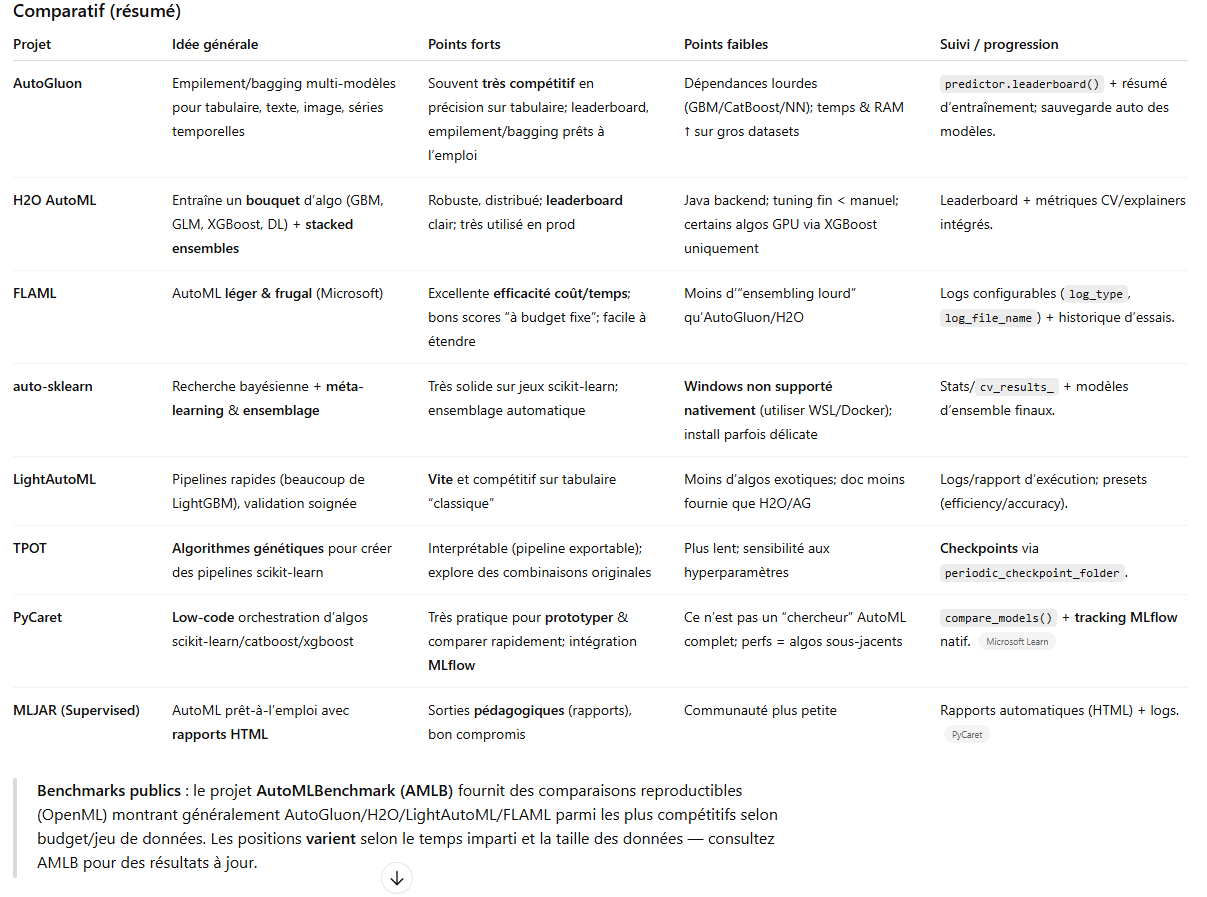